In [354]:
# clear all to reset
import os
os.system('clear')

# clear jupyter notebook
from IPython.display import clear_output
clear_output()


In [355]:
import pandas as pd
import pandas as pd

df = pd.read_csv(r'/Users/ffmacair/Documents/GitWorks/PhD/Rewire_Project/OneDrive_1_12-27-2024/all-fing-ext-2024-10-08-15-14-03_Pro.csv')
# Show the first few rows of the DataFrame
df.head()

# read second file
#df2 = pd.read_csv(r'C:\Users\FireP1-Labster\Documents\gitworks\Rewire_Project\Data\2024-11-20-16-58-52_hand-tracking-landmarks1.csv')
# Show the first few rows of the DataFrame
#df2.head()

,timestamp,landmark_index,x,y,z
0,2024-10-08 15:23:50.555134,0,0.517503,0.373227,-2.927693e-07
1,2024-10-08 15:23:50.555134,1,0.590163,0.425161,2.426312e-02
2,2024-10-08 15:23:50.555134,2,0.631243,0.526908,3.250477e-02
3,2024-10-08 15:23:50.555134,3,0.652604,0.616665,3.756385e-02
4,2024-10-08 15:23:50.555134,4,0.670406,0.677927,4.509268e-02


In [356]:
# Group by timestamp to process each frame separately
grouped_frames = df.groupby('timestamp')

# Inspect the first frame (group of landmarks)
first_frame = grouped_frames.get_group(df['timestamp'].unique()[0])
print(first_frame)
print(grouped_frames)

# Do the same for the second file
# grouped_frames2 = df2.groupby('timestamp')
# first_frame2 = grouped_frames2.get_group(df2['timestamp'].unique()[0])
# print(first_frame2)
# print(grouped_frames2)


                       timestamp  landmark_index         x         y  \
0     2024-10-08 15:23:50.555134               0  0.517503  0.373227   
1     2024-10-08 15:23:50.555134               1  0.590163  0.425161   
2     2024-10-08 15:23:50.555134               2  0.631243  0.526908   
3     2024-10-08 15:23:50.555134               3  0.652604  0.616665   
4     2024-10-08 15:23:50.555134               4  0.670406  0.677927   
5     2024-10-08 15:23:50.555134               5  0.628955  0.601481   
6     2024-10-08 15:23:50.555134               6  0.641931  0.740713   
7     2024-10-08 15:23:50.555134               7  0.632719  0.753983   
8     2024-10-08 15:23:50.555134               8  0.622736  0.728174   
9     2024-10-08 15:23:50.555134               9  0.586724  0.618074   
10    2024-10-08 15:23:50.555134              10  0.598640  0.759843   
11    2024-10-08 15:23:50.555134              11  0.595293  0.743052   
12    2024-10-08 15:23:50.555134              12  0.590136  0.70

In [357]:
import numpy as np
import pandas as pd

# Function to calculate the angle between three points (landmarks)
def calculate_angle(a, b, c):
    # Ensure no None values are passed for the calculation
    if None in (a[0], a[1], a[2], b[0], b[1], b[2], c[0], c[1], c[2]):
        return None  # Return None or NaN if any coordinate is missing
    
    # Vector AB and BC
    v1 = np.array([a[0] - b[0], a[1] - b[1], a[2] - b[2]])  # Vector AB
    v2 = np.array([c[0] - b[0], c[1] - b[1], c[2] - b[2]])  # Vector BC

    # Dot product and magnitudes
    dot_product = np.dot(v1, v2)
    magnitude_v1 = np.linalg.norm(v1)
    magnitude_v2 = np.linalg.norm(v2)

    # Avoid division by zero
    if magnitude_v1 == 0 or magnitude_v2 == 0:
        return None

    # Cosine of the angle between v1 and v2
    cos_angle = dot_product / (magnitude_v1 * magnitude_v2)

    # Return the angle in degrees
    angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))  # Ensure the value is in the range [-1, 1]
    return np.degrees(angle)


In [358]:
# Put the landmarks into marker_positions variable, with timestamp and landmark columns
marker_positions = df[['timestamp', 'landmark_index', 'x', 'y', 'z']]
#marker_positions2 = df2[['timestamp', 'landmark_index', 'x', 'y', 'z']]



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65604 entries, 0 to 65603
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   timestamp       65604 non-null  object 
 1   landmark_index  65604 non-null  int64  
 2   x               65604 non-null  float64
 3   y               65604 non-null  float64
 4   z               65604 non-null  float64
dtypes: float64(3), int64(1), object(1)
memory usage: 2.5+ MB
None

First few rows:
                    timestamp  landmark_index         x         y  \
0  2024-10-08 15:23:49.034886               0  0.517268  0.372634   
1  2024-10-08 15:23:49.034886               1  0.589825  0.424795   
2  2024-10-08 15:23:49.034886               2  0.631023  0.526786   
3  2024-10-08 15:23:49.034886               3  0.652449  0.616478   
4  2024-10-08 15:23:49.034886               4  0.670189  0.677827   

              z  
0 -2.930932e-07  
1  2.430480e-02  
2  3.27

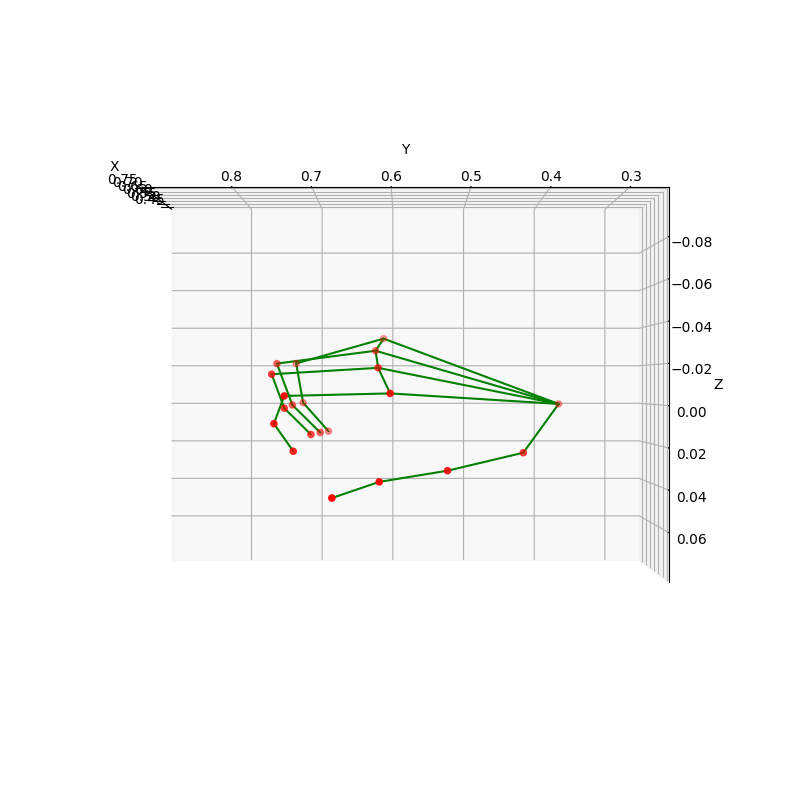

0        1.728401e+09
1        1.728401e+09
2        1.728401e+09
3        1.728401e+09
4        1.728401e+09
             ...     
65599    1.728401e+09
65600    1.728401e+09
65601    1.728401e+09
65602    1.728401e+09
65603    1.728401e+09
Name: timestamp_numeric, Length: 65604, dtype: float64


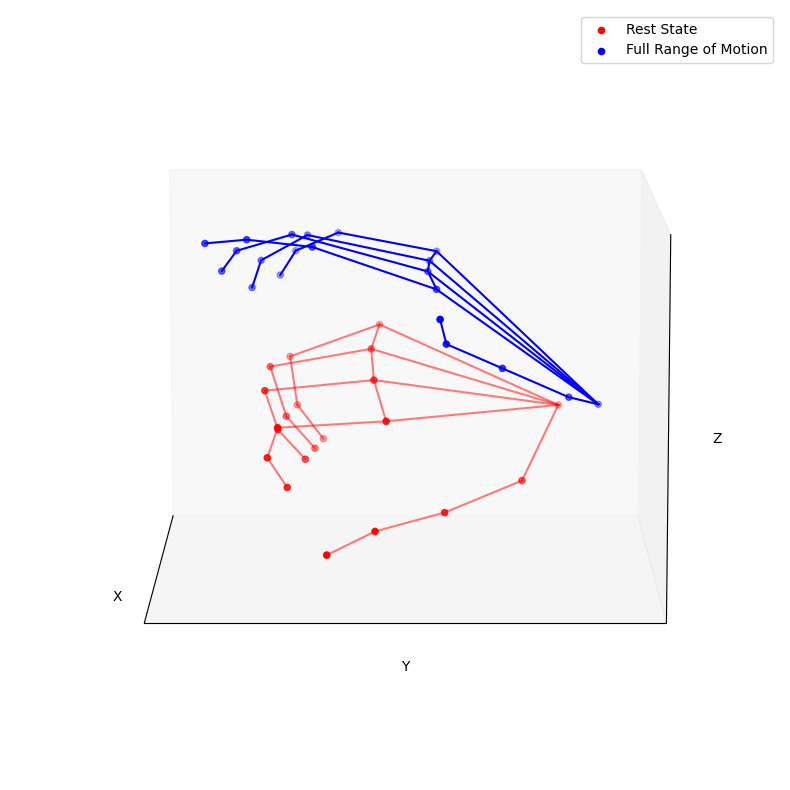

In [359]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from scipy.signal import butter, filtfilt

# Define hand connections
hand_connections = [
        (0, 1), (1, 2), (2, 3), (3, 4),    # Thumb
        (0, 5), (5, 6), (6, 7), (7, 8),    # Index finger
        (0, 9), (9, 10), (10, 11), (11, 12),    # Middle finger
        (0, 13), (13, 14), (14, 15), (15, 16),  # Ring finger
        (0, 17), (17, 18), (18, 19), (19, 20),  # Pinky
        (5, 9), (9, 13), (13, 17)  # Metacarpal connections
]

# Function to apply a low-pass filter
def low_pass_filter(data, cutoff=1, fs=30, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data, axis=0)
    return y
# Create smoothed DataFrames with all columns including timestamp and landmark_index
def smooth_by_landmark(df):
    """Apply low-pass filter per landmark coordinates."""
    smoothed_data = []
    
    # Process each landmark separately
    for landmark in range(21):  # MediaPipe has 21 landmarks
        # Get data for this landmark
        landmark_data = df[df['landmark_index'] == landmark].copy()
        
        # Smooth x, y, z coordinates for this landmark
        landmark_data['x'] = low_pass_filter(landmark_data['x'].values)
        landmark_data['y'] = low_pass_filter(landmark_data['y'].values)
        landmark_data['z'] = low_pass_filter(landmark_data['z'].values)
        
        smoothed_data.append(landmark_data)
    
    # Combine all landmarks back together and sort by timestamp
    return pd.concat(smoothed_data).sort_values(['timestamp', 'landmark_index']).reset_index(drop=True)

# Apply to both cameras
smoothed_marker_positions_df = smooth_by_landmark(marker_positions)

def create_hand_animation(df):
    """Create 3D animation from landmarks DataFrame with hand connections."""


    frames_data = []
    for _, frame_data in df.groupby('timestamp'):
        # Sort by landmark_index to ensure correct order
        frame_data = frame_data.sort_values('landmark_index')
        coords = frame_data[['x', 'y', 'z']].values
        # Coordinate transformations for right hand palm-up:
        # coords[:, 0] = -coords[:, 0]  # Invert X (mirror horizontally)
        # coords[:, 1] = -coords[:, 1]  # Invert Y (flip vertically) 
        # coords[:, 2] = -coords[:, 2]  # Invert Z (palm facing up)
    
        frames_data.append(coords)
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Initial scatter with labels
    scatter = ax.scatter(
        frames_data[0][:, 0],
        frames_data[0][:, 1],
        frames_data[0][:, 2],
        c='r',
        marker='o'
    )
    
    # Draw connections
    lines = []
    for connection in hand_connections:
        start_idx, end_idx = connection
        start_point = frames_data[0][start_idx]
        end_point = frames_data[0][end_idx]
        line = ax.plot(
            [start_point[0], end_point[0]],
            [start_point[1], end_point[1]],
            [start_point[2], end_point[2]],
            c='g'
        )[0]
        lines.append(line)

    # Print first frame coordinates for debugging
    print("First frame landmark positions:")
    for i in range(21):
        print(f"Landmark {i}: {frames_data[0][i]}")
    
    # Set labels and bounds
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    all_coords = np.vstack(frames_data)
    mins = np.min(all_coords, axis=0)
    maxs = np.max(all_coords, axis=0)
    padding = 0.1 * (maxs - mins)
    
    ax.set_xlim(mins[0] - padding[0], maxs[0] + padding[0])
    ax.set_ylim(mins[1] - padding[1], maxs[1] + padding[1])
    ax.set_zlim(mins[2] - padding[2], maxs[2] + padding[2])

    # Rotate plot 
    def update(frame):
        # Update points
        scatter._offsets3d = (
            frames_data[frame][:, 0],
            frames_data[frame][:, 1],
            frames_data[frame][:, 2]
        )
        
        # Update lines
        for idx, (line, connection) in enumerate(zip(lines, hand_connections)):
            start_idx, end_idx = connection
            start_point = frames_data[frame][start_idx]
            end_point = frames_data[frame][end_idx]
            line.set_data_3d(
                [start_point[0], end_point[0]],
                [start_point[1], end_point[1]],
                [start_point[2], end_point[2]]
            )
        
        # Calculate mirrored angles
        # 120 elev and 90 azim for hands down position with - x coord
        # 270 elev and 90 azim for hands up position with + x coord
        mirrored_elev = 180
        mirrored_azim = 180

        # Set mirrored view
        ax.view_init(elev=mirrored_elev, azim=mirrored_azim)

        return [scatter] + lines

    ani = FuncAnimation(
        fig,
        update,
        frames=len(frames_data),
        interval=50,
        blit=True
    )
    
    return fig, ani

# Usage
try:
    print("\nDataFrame info:")
    print(smoothed_marker_positions_df.info())
    print("\nFirst few rows:")
    print(smoothed_marker_positions_df.head())
    
    fig, ani = create_hand_animation(smoothed_marker_positions_df)
    plt.show()
    #ani.save('hand_animation.gif', writer=PillowWriter(fps=30))
    
except Exception as e:
    print(f"Animation error: {str(e)}")


# Plot the first frame, the half-way frame, and the last frame of the smoothed data in 3D in the same plot, with the hand connections, and the hand in the same orientation for all frames, with the palm facing up and the fingers pointing to the right, use different colors for each frame.

# Create a function to plot the hand in 3D
def plot_hand_3d(ax, coords, connections, color='r', alpha=1.0):
    # Plot the hand landmarks
    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=color)
    
    # Plot the connections
    for connection in connections:
        start_idx, end_idx = connection
        start_point = coords[start_idx]
        end_point = coords[end_idx]
        ax.plot([start_point[0], end_point[0]], [start_point[1], end_point[1]], [start_point[2], end_point[2]], c=color, alpha = alpha)

# Function to anchor coordinates to landmark 0
def anchor_to_landmark_0(coords):
    anchor = coords[5]
    return coords - anchor

# Create a figure and 3D axes
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Convert the timestamp column to Unix timestamps
smoothed_marker_positions_df['timestamp_numeric'] = pd.to_datetime(smoothed_marker_positions_df['timestamp']).astype('int64') / 10**9

# Print timestamps numeric
print(smoothed_marker_positions_df['timestamp_numeric'])

# Get the first frame
first_frame_coords = smoothed_marker_positions_df[smoothed_marker_positions_df['timestamp'] == smoothed_marker_positions_df['timestamp'].min()][['x', 'y', 'z']].values

# Get the x seconds frame
x_seconds = 47
x_seconds_timestamp = smoothed_marker_positions_df['timestamp_numeric'].min() + x_seconds
x_seconds_coords = smoothed_marker_positions_df[smoothed_marker_positions_df['timestamp_numeric'] >= x_seconds_timestamp].head(21)[['x', 'y', 'z']].values

last_frame_coords = x_seconds_coords
# Anchor the coordinates to landmark 0
# first_frame_coords = anchor_to_landmark_0(first_frame_coords)
# last_frame_coords = anchor_to_landmark_0(last_frame_coords)

# Plot the hand for each frame
plot_hand_3d(ax, first_frame_coords, hand_connections, color='r', alpha=0.5)
plot_hand_3d(ax, last_frame_coords, hand_connections, color='b', alpha=1.0)

# Set labels and bounds
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

mirrored_elev = 190
mirrored_azim = 180

# Set mirrored view
ax.view_init(elev=mirrored_elev, azim=mirrored_azim)

all_coords = np.vstack([first_frame_coords,  last_frame_coords])
mins = np.min(all_coords, axis=0)
maxs = np.max(all_coords, axis=0)
padding = 0.1 * (maxs - mins)

ax.set_xlim(mins[0] - padding[0], maxs[0] + padding[0])
ax.set_ylim(mins[1] - padding[1], maxs[1] + padding[1])
ax.set_zlim(mins[2] - padding[2], maxs[2] + padding[2])

# Remove axes indicators
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# Legend
ax.scatter([], [], [], c='r', label='Rest State')
ax.scatter([], [], [], c='b', label='Full Range of Motion')

# Show the legend
ax.legend()

plt.savefig('all_fing_ext_47_2.svg', format='svg', dpi=1200)
# Show the plot
plt.show()